In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path
from datetime import datetime
import re
from collections import defaultdict, Counter
import seaborn as sns

# Set up plotting
plt.rcParams['figure.figsize'] = (15, 10)
sns.set_style("whitegrid")

# Target node ID from node-1-log
TARGET_NODE_ID = "12D3KooWCkvtNWBCYzerLWiL9N1jpPJtDWnsoFGeVUQtDhTAiNtx"
LOG_DIR = "logs-backup-20250802-120511"
SESSION_ID = "test-session-1754124500"


In [2]:
def parse_log_files():
    """Parse all log files and extract relevant events"""
    events = []
    node_mappings = {}  # node number to node ID mapping
    
    log_files = sorted(Path(LOG_DIR).glob("node-*-log.log"))
    
    for log_file in log_files:
        node_num = re.search(r'node-(\d+)-log\.log', log_file.name).group(1)
        
        with open(log_file, 'r') as f:
            node_id = None
            
            for line_num, line in enumerate(f, 1):
                line = line.strip()
                if not line:
                    continue
                    
                # Skip non-JSON lines (like config file lines)
                if not line.startswith('{'):
                    continue
                    
                try:
                    log_entry = json.loads(line)
                except json.JSONDecodeError:
                    continue
                
                # Extract node ID from log entries
                if 'node_id' in log_entry and not node_id:
                    node_id = log_entry['node_id']
                    node_mappings[node_num] = node_id
                
                # Extract relevant events
                timestamp = log_entry.get('timestamp', '')
                caller = log_entry.get('caller', '')
                msg = log_entry.get('msg', '')
                level = log_entry.get('level', '')
                
                # Focus on protocol-related events
                if any(protocol in caller for protocol in ['expost', 'exante']):
                    event = {
                        'timestamp': timestamp,
                        'node_num': node_num,
                        'node_id': node_id or f'unknown_{node_num}',
                        'caller': caller,
                        'message': msg,
                        'level': level,
                        'line_num': line_num,
                        'full_entry': log_entry
                    }
                    
                    # Extract additional fields based on message type
                    if 'Received message from' in msg:
                        sender_match = re.search(r'Received message from (.+)', msg)
                        if sender_match:
                            event['sender'] = sender_match.group(1)
                            event['event_type'] = 'message_received'
                    elif 'is a prover, sending initial message' in msg:
                        event['event_type'] = 'prover_identified'
                        event['grade'] = log_entry.get('grade', 0)
                    elif 'SendProtocolMessage' in caller or 'sending' in msg.lower():
                        event['event_type'] = 'message_sent'
                    elif 'Processing valid message' in msg:
                        event['event_type'] = 'message_processing'
                        event['sender_id'] = log_entry.get('sender id', '')
                        event['round'] = log_entry.get('round', 0)
                        event['grade'] = log_entry.get('grade', 0)
                    elif 'Added to results' in msg:
                        event['event_type'] = 'message_accepted'
                        event['sender_id'] = log_entry.get('sender id', '')
                        event['grade'] = log_entry.get('grade', 0)
                    elif 'Message validation failed' in msg or 'filtered out' in msg.lower():
                        event['event_type'] = 'message_rejected'
                        event['sender_id'] = log_entry.get('sender id', '')
                        event['round'] = log_entry.get('round', 0)
                    elif 'verification round' in msg.lower():
                        event['event_type'] = 'round_start'
                        event['round'] = log_entry.get('round', 0)
                    elif 'Initialized neighbors' in msg:
                        event['event_type'] = 'neighbors_initialized'
                        event['num_neighbors'] = log_entry.get('num_neighbors', 0)
                        event['neighbors'] = log_entry.get('neighbors', [])
                        
                    events.append(event)
    
    print(f"Parsed {len(log_files)} log files")
    print(f"Extracted {len(events)} relevant events")
    print(f"Node mappings: {len(node_mappings)}")
    
    return events, node_mappings

# Parse the logs
events, node_mappings = parse_log_files()
df = pd.DataFrame(events)

print("\\nEvent types found:")
print(df['event_type'].value_counts())

print(f"\\nTarget node {TARGET_NODE_ID} is node number: {[k for k, v in node_mappings.items() if v == TARGET_NODE_ID]}")


Parsed 20 log files
Extracted 5487 relevant events
Node mappings: 20
\nEvent types found:
event_type
message_received         1529
round_start               780
message_processing        518
message_accepted          256
neighbors_initialized      40
prover_identified          28
Name: count, dtype: int64
\nTarget node 12D3KooWCkvtNWBCYzerLWiL9N1jpPJtDWnsoFGeVUQtDhTAiNtx is node number: ['1']


In [3]:
def analyze_target_node_behavior():
    """Analyze the target node's behavior as a prover"""
    target_events = df[df['node_id'] == TARGET_NODE_ID].copy()
    target_events['timestamp'] = pd.to_datetime(target_events['timestamp'])
    target_events = target_events.sort_values('timestamp')
    
    print(f"=== Analysis of Target Node: {TARGET_NODE_ID} ===")
    print(f"Total events for target node: {len(target_events)}")
    
    # Check if node was identified as prover
    prover_events = target_events[target_events['event_type'] == 'prover_identified']
    print(f"\\nProver identification events: {len(prover_events)}")
    
    for _, event in prover_events.iterrows():
        print(f"  - {event['timestamp']}: {event['message']} (Grade: {event.get('grade', 'N/A')})")
        protocol = 'ExPost' if 'expost' in event['caller'] else 'ExAnte'
        print(f"    Protocol: {protocol}")
    
    # Check neighbor initialization
    neighbor_events = target_events[target_events['event_type'] == 'neighbors_initialized']
    print(f"\\nNeighbor initialization events: {len(neighbor_events)}")
    
    for _, event in neighbor_events.iterrows():
        print(f"  - {event['timestamp']}: {event['num_neighbors']} neighbors")
        print(f"    Protocol: {'ExPost' if 'expost' in event['caller'] else 'ExAnte'}")
        if event.get('neighbors'):
            print(f"    Neighbors: {event['neighbors'][:5]}...")  # Show first 5
    
    # Check message sending
    sent_events = target_events[target_events['event_type'] == 'message_sent']
    print(f"\\nMessage sending events: {len(sent_events)}")
    
    for _, event in sent_events.iterrows():
        print(f"  - {event['timestamp']}: {event['message']}")
        protocol = 'ExPost' if 'expost' in event['caller'] else 'ExAnte'
        print(f"    Protocol: {protocol}")
    
    return target_events

target_events = analyze_target_node_behavior()


=== Analysis of Target Node: 12D3KooWCkvtNWBCYzerLWiL9N1jpPJtDWnsoFGeVUQtDhTAiNtx ===
Total events for target node: 312
\nProver identification events: 2
  - 2025-08-02 11:59:36.111000+03:00: Node is a prover, sending initial message (Grade: 6.0)
    Protocol: ExPost
  - 2025-08-02 11:59:36.113000+03:00: Node is a prover, sending initial message (Grade: 6.0)
    Protocol: ExAnte
\nNeighbor initialization events: 2
  - 2025-08-02 11:54:56.101000+03:00: 6.0 neighbors
    Protocol: ExPost
    Neighbors: ['12D3KooWQzZKx22DmitQNvY3ukubRgZcHEdYWeJKVrRFxF3bEALD', '12D3KooWFpGn7hYErkkv5cm6cuatwiACLXqJ3izJ9yQNSKLaxRht', '12D3KooWF82ZJrKMq2TipqqWXBzYh9buimCpEpv9GX6h3DhEf9N7', '12D3KooWNxFTWoqck3wNAZEgTbcn7HxmkmPjy2fe3ztuKv99HuYL', '12D3KooWRiebhJGfZM7M21oYRyyhEbkvdeJMRm9UdbFBCWKYMyhN']...
  - 2025-08-02 11:59:16.101000+03:00: 6.0 neighbors
    Protocol: ExAnte
    Neighbors: ['12D3KooWFpGn7hYErkkv5cm6cuatwiACLXqJ3izJ9yQNSKLaxRht', '12D3KooWF82ZJrKMq2TipqqWXBzYh9buimCpEpv9GX6h3DhEf9N7', '12D3KooW

In [4]:
def trace_message_propagation():
    """Trace how messages from the target node propagate through the network"""
    
    # Find all events where nodes received/processed messages from our target node
    target_message_events = df[
        (df['event_type'].isin(['message_received', 'message_processing', 'message_accepted', 'message_rejected'])) &
        (df['sender_id'] == TARGET_NODE_ID)
    ].copy()
    
    target_message_events['timestamp'] = pd.to_datetime(target_message_events['timestamp'])
    target_message_events = target_message_events.sort_values('timestamp')
    
    print(f"=== Message Propagation from Target Node ===")
    print(f"Total events related to target node's messages: {len(target_message_events)}")
    
    # Group by receiving node
    propagation_by_node = target_message_events.groupby('node_id').agg({
        'event_type': list,
        'timestamp': ['min', 'max', 'count'],
        'round': lambda x: list(set([r for r in x if pd.notna(r)])),
        'caller': lambda x: list(set(x))
    }).round(2)
    
    print(f"\\nNodes that received messages from target node: {len(propagation_by_node)}")
    
    # Analyze by event type
    print("\\nMessage propagation by event type:")
    event_counts = target_message_events.groupby(['node_id', 'event_type']).size().unstack(fill_value=0)
    print(event_counts)
    
    # Check which nodes accepted vs rejected messages
    accepted_nodes = set(target_message_events[target_message_events['event_type'] == 'message_accepted']['node_id'])
    rejected_nodes = set(target_message_events[target_message_events['event_type'] == 'message_rejected']['node_id'])
    
    print(f"\\nNodes that ACCEPTED target's messages: {len(accepted_nodes)}")
    for node in accepted_nodes:
        node_num = [k for k, v in node_mappings.items() if v == node]
        print(f"  - {node} (node-{node_num[0] if node_num else 'unknown'})")
    
    print(f"\\nNodes that REJECTED target's messages: {len(rejected_nodes)}")
    for node in rejected_nodes:
        node_num = [k for k, v in node_mappings.items() if v == node]
        print(f"  - {node} (node-{node_num[0] if node_num else 'unknown'})")
    
    # Check timing of propagation
    if len(target_message_events) > 0:
        first_msg = target_message_events.iloc[0]
        last_msg = target_message_events.iloc[-1]
        print(f"\\nPropagation timeline:")
        print(f"  First message received: {first_msg['timestamp']}")
        print(f"  Last message received: {last_msg['timestamp']}")
        print(f"  Propagation duration: {last_msg['timestamp'] - first_msg['timestamp']}")
    
    return target_message_events, event_counts

propagation_events, event_counts = trace_message_propagation()


=== Message Propagation from Target Node ===
Total events related to target node's messages: 60
\nNodes that received messages from target node: 16
\nMessage propagation by event type:
event_type                                          message_accepted  \
node_id                                                                
12D3KooWAmi6SR1XdXQMhCNj5QU5ZSHYmZSx3CoPPmwFrfJ...                 1   
12D3KooWCkvtNWBCYzerLWiL9N1jpPJtDWnsoFGeVUQtDhT...                 1   
12D3KooWEcbdqf6S9oou2bZVN7UhzGQ2DHXDEb91YKwRbKD...                 1   
12D3KooWF6H9SgEg3v4vuvKjP6Z2WAzzHTk9xTvHykxb79e...                 1   
12D3KooWF82ZJrKMq2TipqqWXBzYh9buimCpEpv9GX6h3Dh...                 2   
12D3KooWFeSQVKb5p3Mf91q92JvVsV5P5LTRrkbSphHEqKZ...                 2   
12D3KooWFpGn7hYErkkv5cm6cuatwiACLXqJ3izJ9yQNSKL...                 2   
12D3KooWG1nhzMG8cgWw7PXa885SV9PnKdjSajMmH25ng67...                 1   
12D3KooWKyxxvmee2Y6NyrrZ7EYM5vh6ffSNswmThtCY6g1...                 1   
12D3KooWM8VBcWAHFEoTa3P

In [5]:
def analyze_message_rejections():
    """Analyze why messages from target node were rejected"""
    
    # Get all rejection events for the target node
    rejection_events = df[
        (df['event_type'] == 'message_rejected') &
        (df['sender_id'] == TARGET_NODE_ID)
    ].copy()
    
    print(f"=== Message Rejection Analysis ===")
    print(f"Total rejections of target node's messages: {len(rejection_events)}")
    
    if len(rejection_events) == 0:
        print("No explicit message rejections found. Checking for other validation failures...")
        
        # Look for debug messages about validation failures
        validation_failures = df[
            (df['level'] == 'DEBUG') &
            (df['message'].str.contains('filtered out|validation failed|invalid', case=False, na=False)) &
            (df['sender_id'] == TARGET_NODE_ID)
        ]
        
        print(f"Validation failure messages: {len(validation_failures)}")
        for _, event in validation_failures.iterrows():
            print(f"  - Node {event['node_num']}: {event['message']}")
            print(f"    Caller: {event['caller']}")
    
    else:
        # Analyze rejection reasons
        rejection_events['timestamp'] = pd.to_datetime(rejection_events['timestamp'])
        rejection_events = rejection_events.sort_values('timestamp')
        
        print("\\nRejection details:")
        for _, event in rejection_events.iterrows():
            print(f"  - Node {event['node_num']} at {event['timestamp']}")
            print(f"    Message: {event['message']}")
            print(f"    Round: {event.get('round', 'N/A')}")
            print(f"    Caller: {event['caller']}")
    
    return rejection_events

def analyze_neighbor_relationships():
    """Analyze neighbor relationships to understand propagation paths"""
    
    # Get neighbor initialization events
    neighbor_events = df[df['event_type'] == 'neighbors_initialized'].copy()
    
    print(f"\\n=== Neighbor Relationship Analysis ===")
    print(f"Neighbor initialization events: {len(neighbor_events)}")
    
    # Build neighbor graph
    network_graph = nx.Graph()
    neighbor_map = {}
    
    for _, event in neighbor_events.iterrows():
        node_id = event['node_id']
        neighbors = event.get('neighbors', [])
        
        if neighbors:
            neighbor_map[node_id] = neighbors
            network_graph.add_node(node_id)
            for neighbor in neighbors:
                network_graph.add_edge(node_id, neighbor)
    
    print(f"\\nNetwork graph: {network_graph.number_of_nodes()} nodes, {network_graph.number_of_edges()} edges")
    
    # Check target node's neighbors
    target_neighbors = neighbor_map.get(TARGET_NODE_ID, [])
    print(f"\\nTarget node's neighbors ({len(target_neighbors)}):")
    for neighbor in target_neighbors[:10]:  # Show first 10
        node_num = [k for k, v in node_mappings.items() if v == neighbor]
        print(f"  - {neighbor} (node-{node_num[0] if node_num else 'unknown'})")
    
    # Check which of target's neighbors actually received its messages
    received_from_target = set(propagation_events['node_id'].unique())
    target_neighbors_set = set(target_neighbors)
    
    print(f"\\nNeighbors that received target's messages: {len(received_from_target & target_neighbors_set)}")
    print(f"Neighbors that did NOT receive target's messages: {len(target_neighbors_set - received_from_target)}")
    
    missing_neighbors = target_neighbors_set - received_from_target
    if missing_neighbors:
        print("\\nNeighbors that did NOT receive messages:")
        for neighbor in list(missing_neighbors)[:5]:  # Show first 5
            node_num = [k for k, v in node_mappings.items() if v == neighbor]
            print(f"  - {neighbor} (node-{node_num[0] if node_num else 'unknown'})")
    
    return network_graph, neighbor_map

rejections = analyze_message_rejections()
network_graph, neighbor_map = analyze_neighbor_relationships()


=== Message Rejection Analysis ===
Total rejections of target node's messages: 0
No explicit message rejections found. Checking for other validation failures...
Validation failure messages: 0
\n=== Neighbor Relationship Analysis ===
Neighbor initialization events: 40
\nNetwork graph: 20 nodes, 53 edges
\nTarget node's neighbors (6):
  - 12D3KooWFpGn7hYErkkv5cm6cuatwiACLXqJ3izJ9yQNSKLaxRht (node-15)
  - 12D3KooWF82ZJrKMq2TipqqWXBzYh9buimCpEpv9GX6h3DhEf9N7 (node-17)
  - 12D3KooWNxFTWoqck3wNAZEgTbcn7HxmkmPjy2fe3ztuKv99HuYL (node-19)
  - 12D3KooWRiebhJGfZM7M21oYRyyhEbkvdeJMRm9UdbFBCWKYMyhN (node-3)
  - 12D3KooWFeSQVKb5p3Mf91q92JvVsV5P5LTRrkbSphHEqKZD5CJn (node-18)
  - 12D3KooWQzZKx22DmitQNvY3ukubRgZcHEdYWeJKVrRFxF3bEALD (node-6)
\nNeighbors that received target's messages: 6
Neighbors that did NOT receive target's messages: 0


In [6]:
def analyze_round_progression():
    """Analyze how rounds progress across the network and identify timing issues"""
    
    # Get all round start events
    round_events = df[df['event_type'] == 'round_start'].copy()
    round_events['timestamp'] = pd.to_datetime(round_events['timestamp'])
    round_events = round_events.sort_values('timestamp')
    
    print(f"=== Round Progression Analysis ===")
    print(f"Total round start events: {len(round_events)}")
    
    if len(round_events) > 0:
        # Analyze round timing by protocol
        for protocol in ['expost', 'exante']:
            protocol_rounds = round_events[round_events['caller'].str.contains(protocol)]
            if len(protocol_rounds) > 0:
                print(f"\\n{protocol.upper()} rounds:")
                round_timing = protocol_rounds.groupby('round')['timestamp'].agg(['min', 'max', 'count'])
                print(round_timing.head(10))
                
                # Check for timing spread within rounds
                timing_spread = (round_timing['max'] - round_timing['min']).dt.total_seconds()
                print(f"\\nTiming spread per round (seconds):")
                print(timing_spread.describe())
    
    # Check message propagation by round
    if len(propagation_events) > 0:
        propagation_events['timestamp'] = pd.to_datetime(propagation_events['timestamp'])
        
        print(f"\\n=== Message Propagation by Round ===")
        round_propagation = propagation_events.groupby(['round', 'event_type']).size().unstack(fill_value=0)
        print(round_propagation)
        
        # Check when propagation stops
        last_accepted_round = propagation_events[
            propagation_events['event_type'] == 'message_accepted'
        ]['round'].max()
        
        last_processed_round = propagation_events[
            propagation_events['event_type'] == 'message_processing'
        ]['round'].max()
        
        print(f"\\nLast round with accepted messages: {last_accepted_round}")
        print(f"Last round with processed messages: {last_processed_round}")

def analyze_detailed_message_flow():
    """Detailed analysis of message flow from target node"""
    
    print(f"\\n=== Detailed Message Flow Analysis ===")
    
    # Look for specific error messages that might explain propagation failures
    error_patterns = [
        'sender not in neighbors',
        'protocol not running',
        'grade function',
        'filter function',
        'merkle path',
        'validation failed'
    ]
    
    for pattern in error_patterns:
        error_events = df[
            df['message'].str.contains(pattern, case=False, na=False) &
            (df['level'].isin(['ERROR', 'WARN', 'DEBUG']))
        ]
        
        if len(error_events) > 0:
            print(f"\\n'{pattern}' errors: {len(error_events)}")
            
            # Check if any involve our target node
            target_related = error_events[
                (error_events['node_id'] == TARGET_NODE_ID) |
                (error_events['sender_id'] == TARGET_NODE_ID) |
                (error_events['message'].str.contains(TARGET_NODE_ID, na=False))
            ]
            
            if len(target_related) > 0:
                print(f"  Related to target node: {len(target_related)}")
                for _, event in target_related.head(3).iterrows():
                    print(f"    - Node {event['node_num']}: {event['message']}")
    
    # Check for duplicate message handling
    duplicate_events = df[df['message'].str.contains('duplicate message', case=False, na=False)]
    target_duplicates = duplicate_events[
        (duplicate_events['sender_id'] == TARGET_NODE_ID) |
        (duplicate_events['message'].str.contains(TARGET_NODE_ID, na=False))
    ]
    
    print(f"\\nDuplicate message events related to target: {len(target_duplicates)}")
    
    # Analyze forwarding behavior
    # Look for nodes that received target's message but didn't forward it
    accepting_nodes = set(propagation_events[
        propagation_events['event_type'] == 'message_accepted'
    ]['node_id'])
    
    print(f"\\nNodes that accepted target's messages: {len(accepting_nodes)}")
    
    # For each accepting node, check if they sent messages afterward
    for node in list(accepting_nodes)[:5]:  # Check first 5
        node_sent_events = df[
            (df['node_id'] == node) &
            (df['event_type'] == 'message_sent')
        ]
        print(f"  Node {[k for k, v in node_mappings.items() if v == node]}: {len(node_sent_events)} sent messages")

analyze_round_progression()
analyze_detailed_message_flow()


=== Round Progression Analysis ===
Total round start events: 780
\nEXPOST rounds:
                                   min                              max  count
round                                                                         
1.0   2025-08-02 12:00:46.101000+03:00 2025-08-02 12:00:46.121000+03:00     20
2.0   2025-08-02 12:00:56.096000+03:00 2025-08-02 12:00:56.123000+03:00     20
3.0   2025-08-02 12:01:06.096000+03:00 2025-08-02 12:01:06.122000+03:00     20
4.0   2025-08-02 12:01:16.097000+03:00 2025-08-02 12:01:16.120000+03:00     20
5.0   2025-08-02 12:01:26.101000+03:00 2025-08-02 12:01:26.120000+03:00     20
6.0   2025-08-02 12:01:36.096000+03:00 2025-08-02 12:01:36.120000+03:00     20
7.0   2025-08-02 12:01:46.097000+03:00 2025-08-02 12:01:46.120000+03:00     20
8.0   2025-08-02 12:01:56.097000+03:00 2025-08-02 12:01:56.120000+03:00     20
9.0   2025-08-02 12:02:06.096000+03:00 2025-08-02 12:02:06.121000+03:00     20
10.0  2025-08-02 12:02:16.097000+03:00 2025-08-02

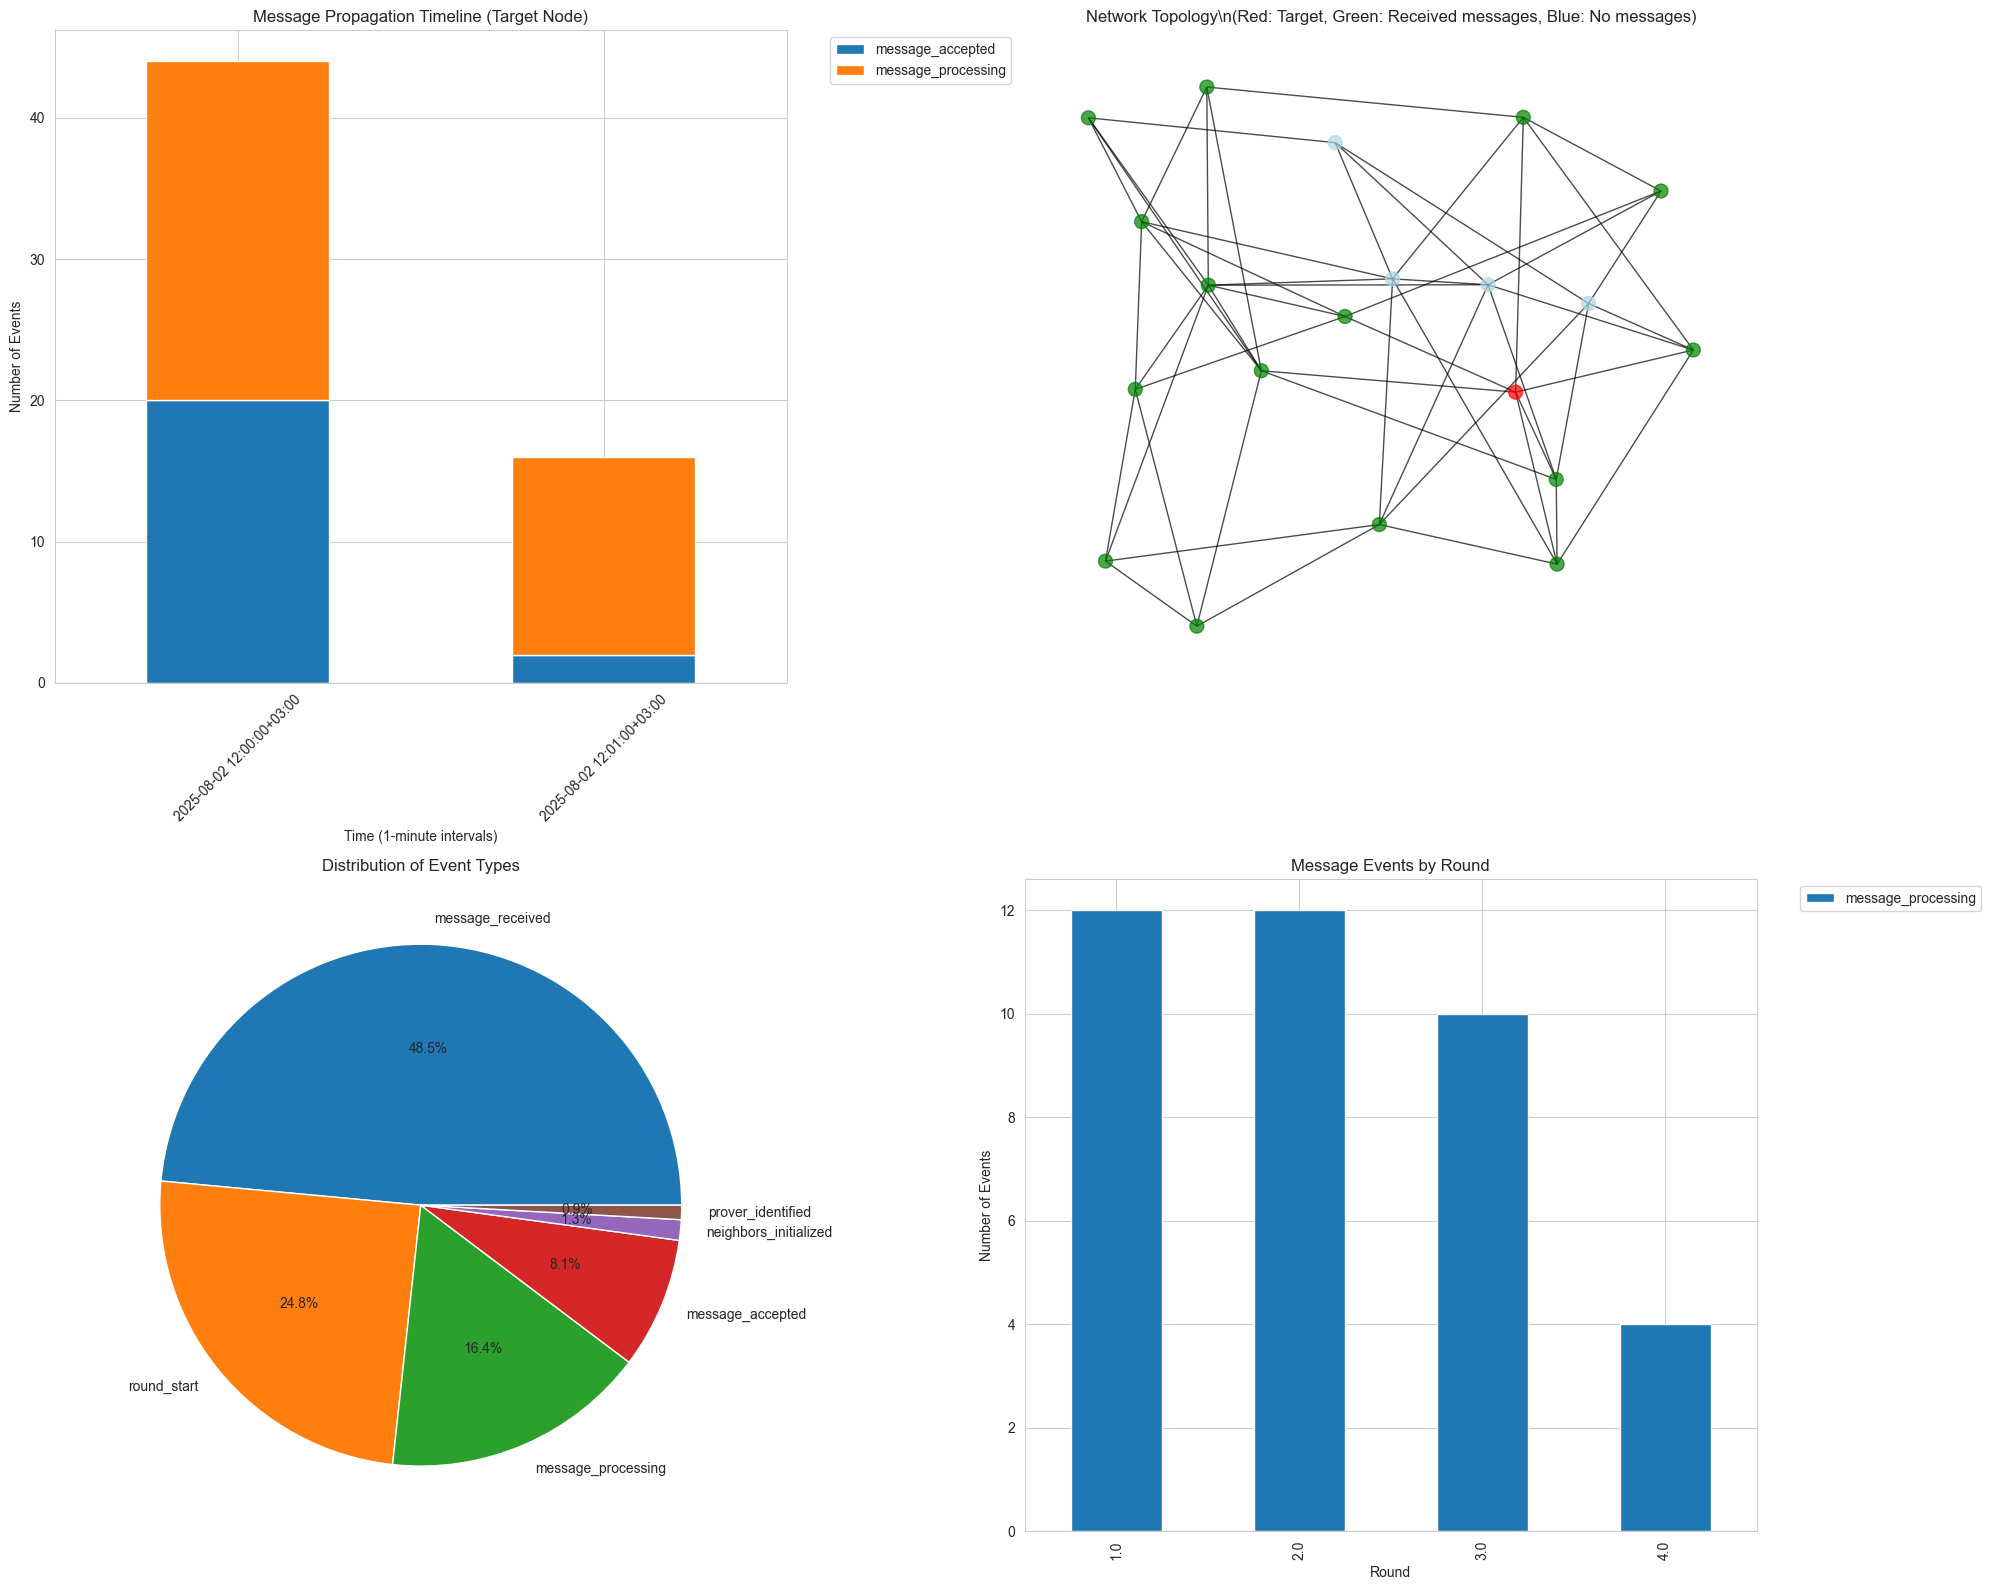

\n============================================================
               PROPAGATION ANALYSIS SUMMARY
\nNetwork Statistics:
  Total nodes in network: 20
  Nodes that received target's messages: 16 (80.0%)
  Nodes that accepted target's messages: 16 (80.0%)
\nTarget Node's Neighbors:
  Total neighbors: 6
  Neighbors that received messages: 6 (100.0%)
\nKey Findings:
  ✅ Message propagation appears healthy
\nProtocol Breakdown:
  ExPost events: 12
  ExAnte events: 48


In [7]:
def create_visualizations():
    """Create visualizations of message propagation and network topology"""
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    
    # 1. Message propagation timeline
    if len(propagation_events) > 0:
        propagation_events['timestamp'] = pd.to_datetime(propagation_events['timestamp'])
        propagation_timeline = propagation_events.groupby([
            propagation_events['timestamp'].dt.floor('1min'), 'event_type'
        ]).size().unstack(fill_value=0)
        
        propagation_timeline.plot(kind='bar', stacked=True, ax=axes[0,0])
        axes[0,0].set_title('Message Propagation Timeline (Target Node)')
        axes[0,0].set_xlabel('Time (1-minute intervals)')
        axes[0,0].set_ylabel('Number of Events')
        axes[0,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        axes[0,0].tick_params(axis='x', rotation=45)
    
    # 2. Network topology with target node highlighted
    if network_graph.number_of_nodes() > 0:
        pos = nx.spring_layout(network_graph, k=1, iterations=50)
        
        # Color nodes based on whether they received target's messages
        node_colors = []
        received_nodes = set(propagation_events['node_id'].unique()) if len(propagation_events) > 0 else set()
        
        for node in network_graph.nodes():
            if node == TARGET_NODE_ID:
                node_colors.append('red')  # Target node
            elif node in received_nodes:
                node_colors.append('green')  # Received target's messages
            else:
                node_colors.append('lightblue')  # Didn't receive
        
        nx.draw(network_graph, pos, ax=axes[0,1], node_color=node_colors, 
                node_size=100, with_labels=False, alpha=0.7)
        axes[0,1].set_title('Network Topology\\n(Red: Target, Green: Received messages, Blue: No messages)')
    
    # 3. Event type distribution
    event_dist = df['event_type'].value_counts()
    event_dist.plot(kind='pie', ax=axes[1,0], autopct='%1.1f%%')
    axes[1,0].set_title('Distribution of Event Types')
    axes[1,0].set_ylabel('')
    
    # 4. Message propagation by round
    if len(propagation_events) > 0 and 'round' in propagation_events.columns:
        round_data = propagation_events.groupby('round')['event_type'].value_counts().unstack(fill_value=0)
        if not round_data.empty:
            round_data.plot(kind='bar', ax=axes[1,1])
            axes[1,1].set_title('Message Events by Round')
            axes[1,1].set_xlabel('Round')
            axes[1,1].set_ylabel('Number of Events')
            axes[1,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

def create_propagation_summary():
    """Create a summary of the propagation analysis"""
    
    print("\\n" + "="*60)
    print("               PROPAGATION ANALYSIS SUMMARY")
    print("="*60)
    
    total_nodes = len(node_mappings)
    nodes_received = len(set(propagation_events['node_id'].unique())) if len(propagation_events) > 0 else 0
    nodes_accepted = len(set(propagation_events[
        propagation_events['event_type'] == 'message_accepted'
    ]['node_id'].unique())) if len(propagation_events) > 0 else 0
    
    print(f"\\nNetwork Statistics:")
    print(f"  Total nodes in network: {total_nodes}")
    print(f"  Nodes that received target's messages: {nodes_received} ({nodes_received/total_nodes*100:.1f}%)")
    print(f"  Nodes that accepted target's messages: {nodes_accepted} ({nodes_accepted/total_nodes*100:.1f}%)")
    
    if TARGET_NODE_ID in neighbor_map:
        target_neighbor_count = len(neighbor_map[TARGET_NODE_ID])
        neighbors_received = len(set(neighbor_map[TARGET_NODE_ID]) & set(propagation_events['node_id'].unique())) if len(propagation_events) > 0 else 0
        print(f"\\nTarget Node's Neighbors:")
        print(f"  Total neighbors: {target_neighbor_count}")
        print(f"  Neighbors that received messages: {neighbors_received} ({neighbors_received/target_neighbor_count*100:.1f}%)")
    
    # Key findings
    print(f"\\nKey Findings:")
    
    if nodes_received == 0:
        print("  ❌ CRITICAL: No nodes received messages from target node")
        print("     This suggests the target node may not have sent any messages")
    elif nodes_received < total_nodes * 0.5:
        print("  ⚠️  WARNING: Message propagation is limited (< 50% of nodes)")
        print("     Check neighbor relationships and message validation")
    elif nodes_accepted < nodes_received * 0.5:
        print("  ⚠️  WARNING: High message rejection rate")
        print("     Check validation logic (grade function, filters, merkle paths)")
    else:
        print("  ✅ Message propagation appears healthy")
    
    # Protocol-specific analysis
    expost_events = propagation_events[propagation_events['caller'].str.contains('expost', na=False)] if len(propagation_events) > 0 else []
    exante_events = propagation_events[propagation_events['caller'].str.contains('exante', na=False)] if len(propagation_events) > 0 else []
    
    print(f"\\nProtocol Breakdown:")
    print(f"  ExPost events: {len(expost_events)}")
    print(f"  ExAnte events: {len(exante_events)}")

create_visualizations()
create_propagation_summary()


In [8]:
def deep_dive_analysis():
    """Perform deep dive analysis to identify root causes"""
    
    print("\\n" + "="*60)
    print("                DEEP DIVE ANALYSIS")
    print("="*60)
    
    # 1. Check if target node actually sent messages
    target_node_events = df[df['node_id'] == TARGET_NODE_ID].copy()
    
    # Look for actual protocol message sending in network layer
    network_send_events = target_node_events[
        target_node_events['message'].str.contains('SendProtocolMessage|sending', case=False, na=False)
    ]
    
    print(f"\\n1. Target Node Message Sending:")
    print(f"   Protocol message sends detected: {len(network_send_events)}")
    
    if len(network_send_events) == 0:
        print("   ❌ ISSUE: Target node did not send any protocol messages")
        print("   This could be because:")
        print("     - Node was not identified as a prover")
        print("     - Grade function returned insufficient grade")
        print("     - Filter function rejected the node")
        print("     - Protocol initialization failed")
        
        # Check prover identification
        prover_events = target_node_events[target_node_events['message'].str.contains('prover', case=False, na=False)]
        print(f"\\n   Prover-related events: {len(prover_events)}")
        for _, event in prover_events.iterrows():
            print(f"     - {event['message']}")
    
    # 2. Check neighbor connectivity issues
    print(f"\\n2. Neighbor Connectivity Analysis:")
    
    # Look for connection errors
    connection_errors = df[
        df['message'].str.contains('connection|connect|dial|peer', case=False, na=False) &
        df['level'].isin(['ERROR', 'WARN'])
    ]
    
    target_connection_errors = connection_errors[
        (connection_errors['node_id'] == TARGET_NODE_ID) |
        (connection_errors['message'].str.contains(TARGET_NODE_ID, na=False))
    ]
    
    print(f"   Connection errors involving target: {len(target_connection_errors)}")
    for _, event in target_connection_errors.head(3).iterrows():
        print(f"     - {event['message']}")
    
    # 3. Check protocol state issues
    print(f"\\n3. Protocol State Analysis:")
    
    protocol_not_running = df[
        df['message'].str.contains('protocol not running', case=False, na=False)
    ]
    
    print(f"   'Protocol not running' errors: {len(protocol_not_running)}")
    
    # 4. Analyze message validation failures in detail
    print(f"\\n4. Message Validation Analysis:")
    
    debug_messages = df[
        (df['level'] == 'DEBUG') &
        (df['sender_id'] == TARGET_NODE_ID)
    ]
    
    validation_patterns = {
        'filter_function': 'filtered out by filter function',
        'grade_function': 'filtered out by grade function',
        'merkle_path': 'filtered out by merkle path',
        'neighbor_check': 'sender not in neighbors'
    }
    
    for pattern_name, pattern in validation_patterns.items():
        matches = debug_messages[debug_messages['message'].str.contains(pattern, case=False, na=False)]
        if len(matches) > 0:
            print(f"   {pattern_name} failures: {len(matches)}")
            affected_nodes = matches['node_id'].unique()
            print(f"     Affected nodes: {len(affected_nodes)}")

def check_log_completeness():
    """Check if logs are complete and identify any gaps"""
    
    print(f"\\n5. Log Completeness Check:")
    
    # Check for each node number 1-20
    expected_nodes = set(range(1, 21))
    actual_nodes = set([int(k) for k in node_mappings.keys()])
    missing_nodes = expected_nodes - actual_nodes
    
    print(f"   Expected nodes: {len(expected_nodes)}")
    print(f"   Actual nodes with logs: {len(actual_nodes)}")
    
    if missing_nodes:
        print(f"   Missing node logs: {sorted(missing_nodes)}")
    
    # Check timestamp ranges for each node
    print(f"\\n   Timestamp ranges by node:")
    for node_num in sorted(actual_nodes):
        node_events = df[df['node_num'] == str(node_num)]
        if len(node_events) > 0:
            node_events['timestamp'] = pd.to_datetime(node_events['timestamp'])
            time_range = node_events['timestamp'].max() - node_events['timestamp'].min()
            print(f"     Node {node_num}: {time_range} ({len(node_events)} events)")

def generate_action_items():
    """Generate specific action items based on the analysis"""
    
    print(f"\\n" + "="*60)
    print("                 RECOMMENDED ACTIONS")
    print("="*60)
    
    nodes_received = len(set(propagation_events['node_id'].unique())) if len(propagation_events) > 0 else 0
    
    if nodes_received == 0:
        print("\\n🔍 IMMEDIATE ACTIONS NEEDED:")
        print("1. Verify target node was properly identified as a prover")
        print("2. Check if grade function is working correctly")
        print("3. Verify filter function is not rejecting valid provers")
        print("4. Check network connectivity and neighbor discovery")
        print("5. Verify protocol initialization sequence")
        
        print("\\n📋 DEBUGGING STEPS:")
        print("1. Add more logging to prover identification logic")
        print("2. Log the actual grade calculated for the target node")
        print("3. Log filter function decisions")
        print("4. Verify message marshaling/unmarshaling is working")
        print("5. Check protocol registration and message routing")
    
    else:
        print("\\n🔍 OPTIMIZATION OPPORTUNITIES:")
        print("1. Investigate why some neighbors didn't receive messages")
        print("2. Optimize message validation to reduce rejections")
        print("3. Check round synchronization timing")
        print("4. Verify merkle path validation logic")

# Run deep dive analysis
deep_dive_analysis()
check_log_completeness()
generate_action_items()


\n============================================================
                DEEP DIVE ANALYSIS
\n1. Target Node Message Sending:
   Protocol message sends detected: 2
\n2. Neighbor Connectivity Analysis:
   Connection errors involving target: 0
\n3. Protocol State Analysis:
   'Protocol not running' errors: 0
\n4. Message Validation Analysis:
\n5. Log Completeness Check:
   Expected nodes: 20
   Actual nodes with logs: 20
\n   Timestamp ranges by node:
     Node 1: 0 days 00:15:04.894000 (312 events)
     Node 2: 0 days 00:15:13.216000 (218 events)
     Node 3: 0 days 00:15:05.192000 (327 events)
     Node 4: 0 days 00:15:04.306000 (209 events)
     Node 5: 0 days 00:15:13.216000 (225 events)
     Node 6: 0 days 00:15:04.003000 (289 events)
     Node 7: 0 days 00:15:05.389000 (329 events)
     Node 8: 0 days 00:15:11.875000 (296 events)
     Node 9: 0 days 00:15:03.698000 (207 events)
     Node 10: 0 days 00:15:06.600000 (348 events)
     Node 11: 0 days 00:15:05.878000 (273 events)

/var/folders/ld/rqglbq693g37vv4gt0w2w32c0000gp/T/ipykernel_33211/2540065959.py:103: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  node_events['timestamp'] = pd.to_datetime(node_events['timestamp'])
/var/folders/ld/rqglbq693g37vv4gt0w2w32c0000gp/T/ipykernel_33211/2540065959.py:103: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  node_events['timestamp'] = pd.to_datetime(node_events['timestamp'])
/var/folders/ld/rqglbq693g37vv4gt0w2w32c0000gp/T/ipykernel_33211/2540065959.py:103: SettingWithCopyWarning: 
A value

In [9]:
# Manual inspection utilities
def inspect_specific_events(event_filter=None, max_events=10):
    """Utility for manual inspection of specific events"""
    
    if event_filter:
        filtered_events = df[event_filter].copy()
    else:
        filtered_events = df.copy()
    
    filtered_events['timestamp'] = pd.to_datetime(filtered_events['timestamp'])
    filtered_events = filtered_events.sort_values('timestamp')
    
    print(f"Found {len(filtered_events)} matching events (showing first {max_events}):")
    
    for i, (_, event) in enumerate(filtered_events.head(max_events).iterrows()):
        print(f"\\n{i+1}. {event['timestamp']} - Node {event['node_num']}")
        print(f"   {event['caller']}: {event['message']}")
        print(f"   Level: {event['level']}")
        if event.get('sender_id'):
            print(f"   Sender ID: {event['sender_id']}")
        if event.get('round'):
            print(f"   Round: {event['round']}")

# Examples of manual inspection queries:

print("=== MANUAL INSPECTION UTILITIES ===")
print("\\nUse these examples to dig deeper into specific issues:")
print("\\n1. All events from target node:")
print("inspect_specific_events(df['node_id'] == TARGET_NODE_ID)")

print("\\n2. All message reception events:")
print("inspect_specific_events(df['event_type'] == 'message_received')")

print("\\n3. All errors and warnings:")
print("inspect_specific_events(df['level'].isin(['ERROR', 'WARN']))")

print("\\n4. Debug messages related to target node:")
print("inspect_specific_events((df['level'] == 'DEBUG') & (df['sender_id'] == TARGET_NODE_ID))")

print("\\n5. All prover identification events:")
print("inspect_specific_events(df['event_type'] == 'prover_identified')")

# You can run any of these commands to inspect specific events
# Uncomment the line below to run an example:
# inspect_specific_events(df['node_id'] == TARGET_NODE_ID)


=== MANUAL INSPECTION UTILITIES ===
\nUse these examples to dig deeper into specific issues:
\n1. All events from target node:
inspect_specific_events(df['node_id'] == TARGET_NODE_ID)
\n2. All message reception events:
inspect_specific_events(df['event_type'] == 'message_received')
\n3. All errors and warnings:
inspect_specific_events(df['level'].isin(['ERROR', 'WARN']))
\n4. Debug messages related to target node:
inspect_specific_events((df['level'] == 'DEBUG') & (df['sender_id'] == TARGET_NODE_ID))
\n5. All prover identification events:
inspect_specific_events(df['event_type'] == 'prover_identified')


In [10]:
def analyze_committee_election_results():
    """Analyze committee election results to see which nodes elected the target node"""
    
    print("\\n" + "="*60)
    print("            COMMITTEE ELECTION ANALYSIS")
    print("="*60)
    
    # Search for committee elected messages
    committee_messages = df[
        df['message'].str.contains('Committee elected|committee', case=False, na=False)
    ].copy()
    
    print(f"\\nTotal committee-related messages found: {len(committee_messages)}")
    
    if len(committee_messages) == 0:
        print("No 'Committee elected' messages found in logs")
        print("Checking for other committee-related messages...")
        
        # Look for other patterns that might indicate committee results
        committee_patterns = [
            'committee',
            'elected',
            'results',
            'members',
            'selected'
        ]
        
        for pattern in committee_patterns:
            matches = df[df['message'].str.contains(pattern, case=False, na=False)]
            if len(matches) > 0:
                print(f"\\nMessages containing '{pattern}': {len(matches)}")
                for _, msg in matches.head(3).iterrows():
                    print(f"  - Node {msg['node_num']}: {msg['message']}")
        return
    
    # Analyze committee messages
    committee_messages['timestamp'] = pd.to_datetime(committee_messages['timestamp'])
    committee_messages = committee_messages.sort_values('timestamp')
    
    print("\\nCommittee election messages:")
    nodes_with_committee_results = set()
    target_included_count = 0
    target_excluded_count = 0
    
    for _, msg in committee_messages.iterrows():
        print(f"\\n- Node {msg['node_num']} at {msg['timestamp']}:")
        print(f"  Caller: {msg['caller']}")
        print(f"  Message: {msg['message']}")
        
        # Check if this message contains committee member information
        message_text = msg['message'].lower()
        full_entry = msg.get('full_entry', {})
        
        # Look for the target node ID in the message or log entry
        target_mentioned = (
            TARGET_NODE_ID in str(msg['message']) or
            TARGET_NODE_ID in str(full_entry)
        )
        
        if target_mentioned:
            print(f"  ✅ TARGET NODE INCLUDED in committee")
            target_included_count += 1
        else:
            print(f"  ❌ Target node NOT mentioned in committee")
            target_excluded_count += 1
            
        nodes_with_committee_results.add(msg['node_id'])
        
        # Try to extract additional details from the full log entry
        if isinstance(full_entry, dict):
            # Look for committee-related fields
            for key, value in full_entry.items():
                if 'committee' in key.lower() or 'member' in key.lower():
                    print(f"  {key}: {value}")
    
    print(f"\\n" + "="*40)
    print("COMMITTEE ELECTION SUMMARY")
    print("="*40)
    print(f"Total nodes that produced committee results: {len(nodes_with_committee_results)}")
    print(f"Nodes that INCLUDED target in committee: {target_included_count}")
    print(f"Nodes that EXCLUDED target from committee: {target_excluded_count}")
    
    if target_included_count > 0:
        inclusion_rate = target_included_count / len(nodes_with_committee_results) * 100
        print(f"Target node inclusion rate: {inclusion_rate:.1f}%")
        
        if inclusion_rate < 50:
            print("⚠️  WARNING: Target node included in less than 50% of committees")
            print("   This suggests limited message propagation or validation issues")
        elif inclusion_rate < 100:
            print("⚠️  PARTIAL: Target node not universally included in committees")
            print("   Some nodes may not have received or validated the target's messages")
        else:
            print("✅ SUCCESS: Target node included in all committee results")
    else:
        print("❌ CRITICAL: Target node not included in any committee results")
        print("   This indicates the target node's messages failed to propagate or validate")
    
    return committee_messages

def detailed_committee_analysis():
    """Perform detailed analysis of committee election patterns"""
    
    print("\\n" + "="*60)
    print("          DETAILED COMMITTEE ANALYSIS")
    print("="*60)
    
    # Look for any messages that might contain committee member lists
    potential_committee_data = []
    
    # Search through all log entries for committee-related data
    for _, event in df.iterrows():
        full_entry = event.get('full_entry', {})
        if isinstance(full_entry, dict):
            # Look for fields that might contain committee information
            for key, value in full_entry.items():
                if any(term in key.lower() for term in ['committee', 'member', 'elected', 'selected']):
                    potential_committee_data.append({
                        'node_num': event['node_num'],
                        'node_id': event['node_id'],
                        'timestamp': event['timestamp'],
                        'field': key,
                        'value': value,
                        'message': event['message']
                    })
    
    print(f"\\nPotential committee data entries found: {len(potential_committee_data)}")
    
    if potential_committee_data:
        print("\\nDetailed committee data:")
        for entry in potential_committee_data[:10]:  # Show first 10
            print(f"\\n- Node {entry['node_num']} at {entry['timestamp']}:")
            print(f"  Field: {entry['field']}")
            print(f"  Value: {entry['value']}")
            print(f"  Message: {entry['message']}")
            
            # Check if target node is mentioned in the value
            if isinstance(entry['value'], (str, list)) and TARGET_NODE_ID in str(entry['value']):
                print(f"  🎯 TARGET NODE FOUND in this entry")
    
    # Alternative search: look for the target node ID in any log entry
    print(f"\\n" + "="*40)
    print("TARGET NODE MENTIONS ANALYSIS")
    print("="*40)
    
    target_mentions = []
    for _, event in df.iterrows():
        # Check message content
        if TARGET_NODE_ID in str(event['message']):
            target_mentions.append({
                'node_num': event['node_num'],
                'location': 'message',
                'content': event['message'],
                'timestamp': event['timestamp'],
                'caller': event['caller']
            })
        
        # Check full log entry
        full_entry = event.get('full_entry', {})
        if isinstance(full_entry, dict):
            entry_str = str(full_entry)
            if TARGET_NODE_ID in entry_str and TARGET_NODE_ID not in str(event['message']):
                target_mentions.append({
                    'node_num': event['node_num'],
                    'location': 'log_entry',
                    'content': entry_str[:200] + "..." if len(entry_str) > 200 else entry_str,
                    'timestamp': event['timestamp'],
                    'caller': event['caller']
                })
    
    print(f"\\nTotal mentions of target node ID across all logs: {len(target_mentions)}")
    
    if target_mentions:
        print("\\nTarget node mentions by node:")
        mentions_by_node = {}
        for mention in target_mentions:
            node = mention['node_num']
            if node not in mentions_by_node:
                mentions_by_node[node] = []
            mentions_by_node[node].append(mention)
        
        for node_num in sorted(mentions_by_node.keys(), key=int):
            mentions = mentions_by_node[node_num]
            print(f"\\n  Node {node_num}: {len(mentions)} mentions")
            for mention in mentions[:3]:  # Show first 3 per node
                print(f"    - {mention['timestamp']} ({mention['caller']}): {mention['content'][:100]}...")
    
    return potential_committee_data, target_mentions

# Run the committee analysis
committee_results = analyze_committee_election_results()
committee_data, target_mentions = detailed_committee_analysis()


\n============================================================
            COMMITTEE ELECTION ANALYSIS
\nTotal committee-related messages found: 0
No 'Committee elected' messages found in logs
Checking for other committee-related messages...
\nMessages containing 'results': 256
  - Node 1: Added to results
  - Node 1: Added to results
  - Node 1: Added to results
\n============================================================
          DETAILED COMMITTEE ANALYSIS
\nPotential committee data entries found: 0
\n========================================
TARGET NODE MENTIONS ANALYSIS
\nTotal mentions of target node ID across all logs: 604
\nTarget node mentions by node:
\n  Node 1: 312 mentions
    - 2025-08-02T11:48:51.208+0300 (exante/exante.go:82): {'level': 'INFO', 'timestamp': '2025-08-02T11:48:51.208+0300', 'caller': 'exante/exante.go:82', 'msg...
    - 2025-08-02T11:48:51.208+0300 (expost/expost.go:92): {'level': 'INFO', 'timestamp': '2025-08-02T11:48:51.208+0300', 'caller': 'expost/ex